# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df=pd.read_csv('../data/regression.csv')
df=df.drop('pageviews', axis=1)
df

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
5,user_19,118,-98.750000
6,user_21,65,-95.500000
7,user_25,79,-92.600000
8,user_28,60,-86.400000
9,user_3,18,-105.400000


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [3]:
X = df[['num_commits', 'AVG(diff)']]

kmeans = KMeans(n_clusters=3, random_state=21, n_init='auto')
df['cluster'] = kmeans.fit_predict(X)

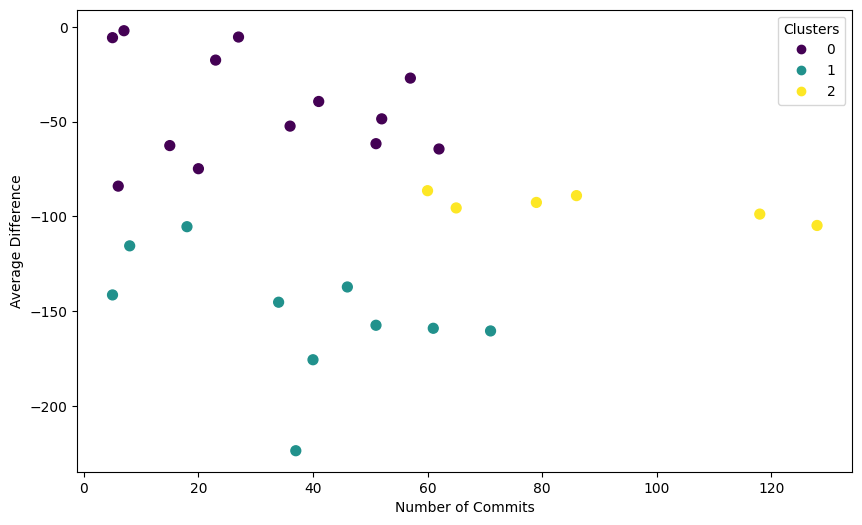

In [4]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['num_commits'], df['AVG(diff)'], c=df['cluster'], cmap='viridis', s=50)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.xlabel('Number of Commits')
plt.ylabel('Average Difference')
plt.show()

In [5]:
silhouette_score(X, df['cluster'])

0.4454402135233297

In [6]:
result=[]
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=21)
    kmeans.fit(X)
    clusters= kmeans.fit_predict(X)
    score = silhouette_score(X, clusters)
    result.append(score)

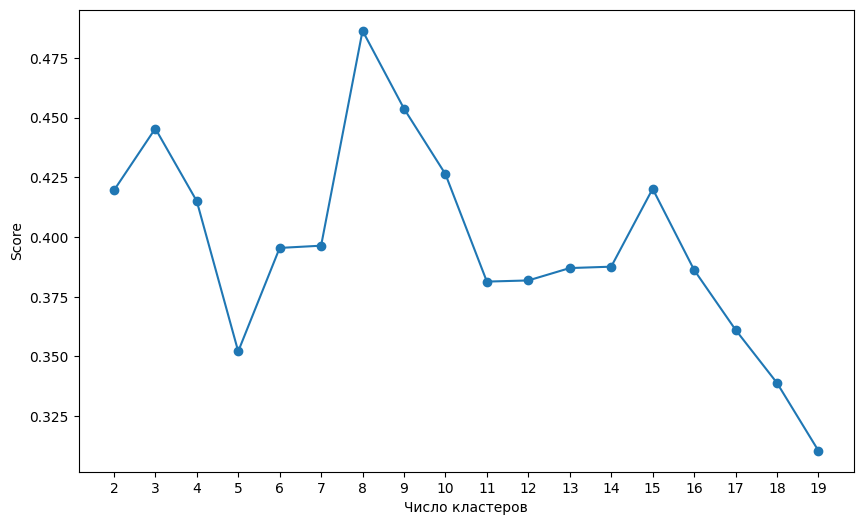

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 20), result, marker="o")
plt.xlabel("Число кластеров")
plt.xticks(range(2, 20))
plt.ylabel("Score")
plt.show()

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [8]:
dbscan = DBSCAN(eps=20, min_samples=2)
df['dbscan_cluster'] = dbscan.fit_predict(X)

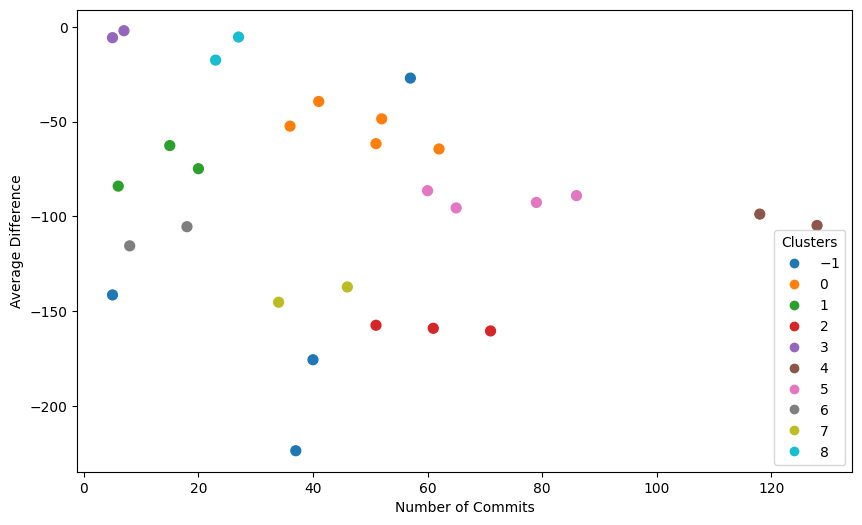

In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['num_commits'], df['AVG(diff)'], c=df['dbscan_cluster'], cmap='tab10', s=50)
# кластер -1 — это шум
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.xlabel('Number of Commits')
plt.ylabel('Average Difference')
plt.show()

In [10]:
silhouette_score(X, df['dbscan_cluster'])

0.38339641455696616

In [11]:
eps_values = np.arange(1, 25, 1)  
min_samples_values = range(1, 10)  

best_score = -1  
best_eps = 0
best_min_samples = 0

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0) 
        
        if 1 < n_clusters < len(X):
            try:
                score = silhouette_score(X, labels)
                if score > best_score:
                    best_score = score
                    best_eps = eps
                    best_min_samples = min_samples
            except ValueError:
                continue 

In [12]:
best_eps

np.int64(22)

In [13]:
best_min_samples

1

In [14]:
dbscan = DBSCAN(eps=20, min_samples=2)
df['dbscan_cluster'] = dbscan.fit_predict(X)

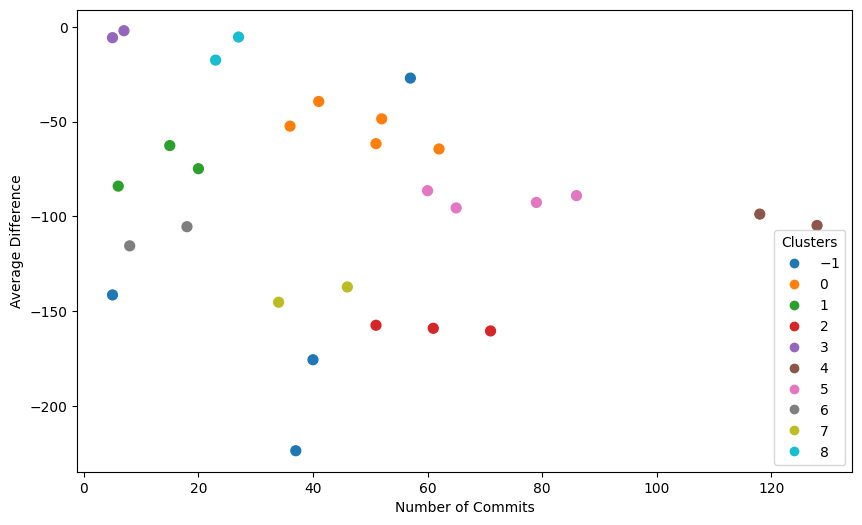

In [15]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['num_commits'], df['AVG(diff)'], c=df['dbscan_cluster'], cmap='tab10', s=50)
# кластер -1 — это шум
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.xlabel('Number of Commits')
plt.ylabel('Average Difference')
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [16]:
agg_clustering = AgglomerativeClustering(n_clusters=5)
clusters_agg = agg_clustering.fit_predict(X)
df['cluster_agg'] = clusters_agg

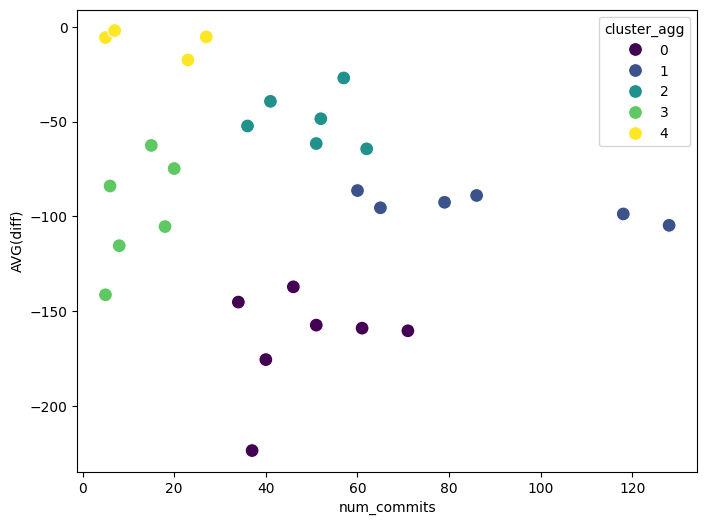

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="num_commits", y="AVG(diff)", hue="cluster_agg", palette="viridis", s=100)
plt.xlabel("num_commits")
plt.ylabel("AVG(diff)")
plt.show()

In [18]:
for n in range(2, 10, 1):
    agg_clustering = AgglomerativeClustering(n_clusters=n)
    clusters = agg_clustering.fit_predict(X)
    print(f"n={n}   {silhouette_score(X, clusters)}")

n=2   0.35902490572221984
n=3   0.3390493703444805
n=4   0.4448362750283643
n=5   0.46383015199381467
n=6   0.4527145606287827
n=7   0.4865808853184314
n=8   0.50779855565622
n=9   0.47576869039147557


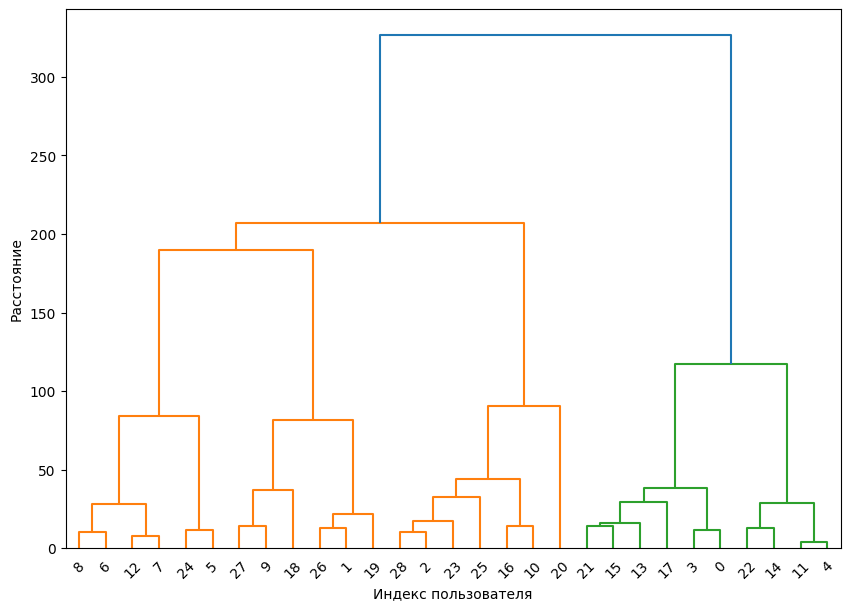

In [19]:
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.xlabel("Индекс пользователя")
plt.ylabel("Расстояние")
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [20]:
def optimize_and_visualize_clustering(model_class, base_params, param_name,param_range, X):
    best_score = -1
    best_value = None
    scores = []
    best_params=None
    for value in param_range:
        params = base_params.copy()
        params[param_name] = int(value)
        
        model = model_class(**params)
        labels = model.fit_predict(X)
        
        
        
        if len(set(labels))> 1:
            score = silhouette_score(X, labels)
            scores.append(score)
                
        
            if score > best_score:
                    best_score = score
                    best_value = value
                    best_params=params
        else:
                scores.append(0)

    print(len(scores))
    plt.figure(figsize=(15, 6))

    
    plt.subplot(1, 2, 1)
    plt.plot(param_range[:len(scores)], scores, 'bo-')
    plt.axvline(x=best_value, color='r', linestyle='--', alpha=0.7)
    plt.xlabel(param_name)
    plt.ylabel('Silhouette Score')
    plt.title(f'Зависимость качества от параметра {param_name}\nЛучшее значение: {best_value} (score={best_score:.3f})')
    plt.grid(True)

    \
    plt.subplot(1, 2, 2)
    agg = model_class(**best_params)
    labels = agg.fit_predict(X)
    df["cluster"] = labels  

    sns.scatterplot(
        data=df,
        x="num_commits",
        y="AVG(diff)",
        hue="cluster",
        palette="viridis",
        s=100
    )
    plt.title("Кластеризация пользователей по num_commits и AVG(diff)")
    plt.xlabel("Количество коммитов (num_commits)")
    plt.ylabel("Средняя разница (AVG(diff))")
    plt.grid()

    plt.tight_layout() 
    plt.show()

22


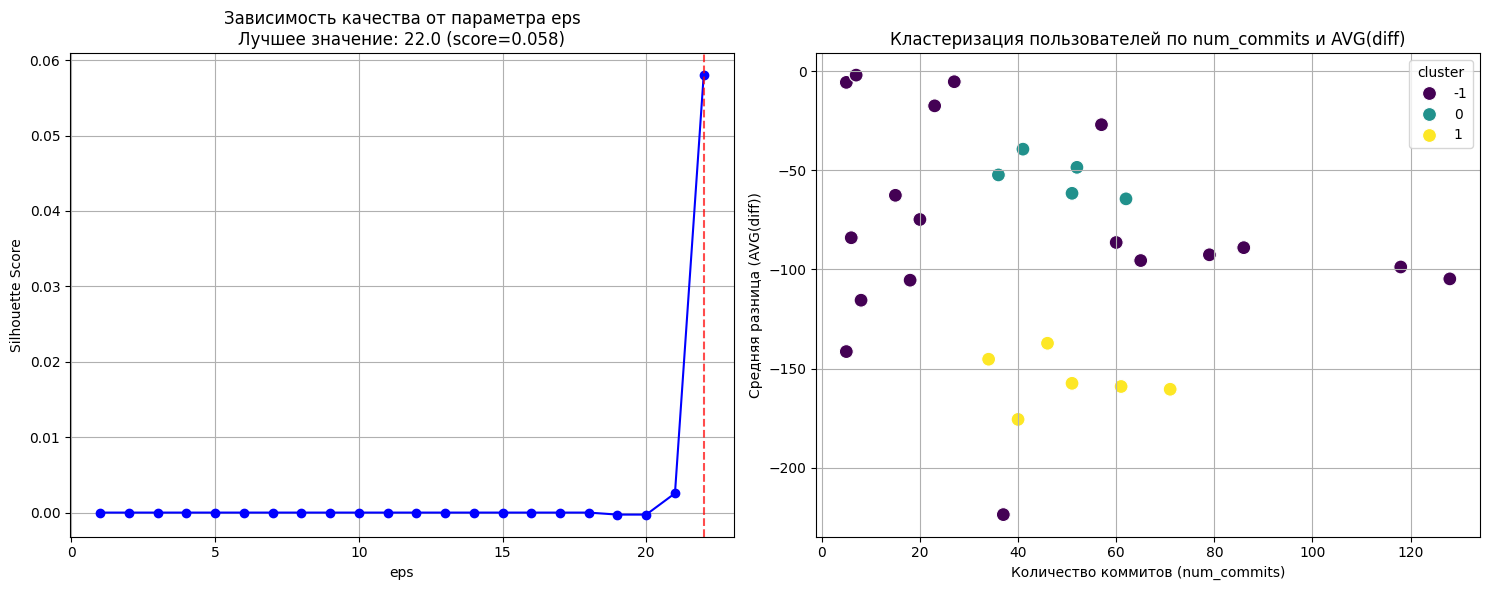

In [21]:
optimize_and_visualize_clustering(
    model_class=DBSCAN,
    base_params={ 'min_samples': 5},
    param_name='eps',
    param_range=np.linspace(1, 22, 22),
    X=X,
    
)

10


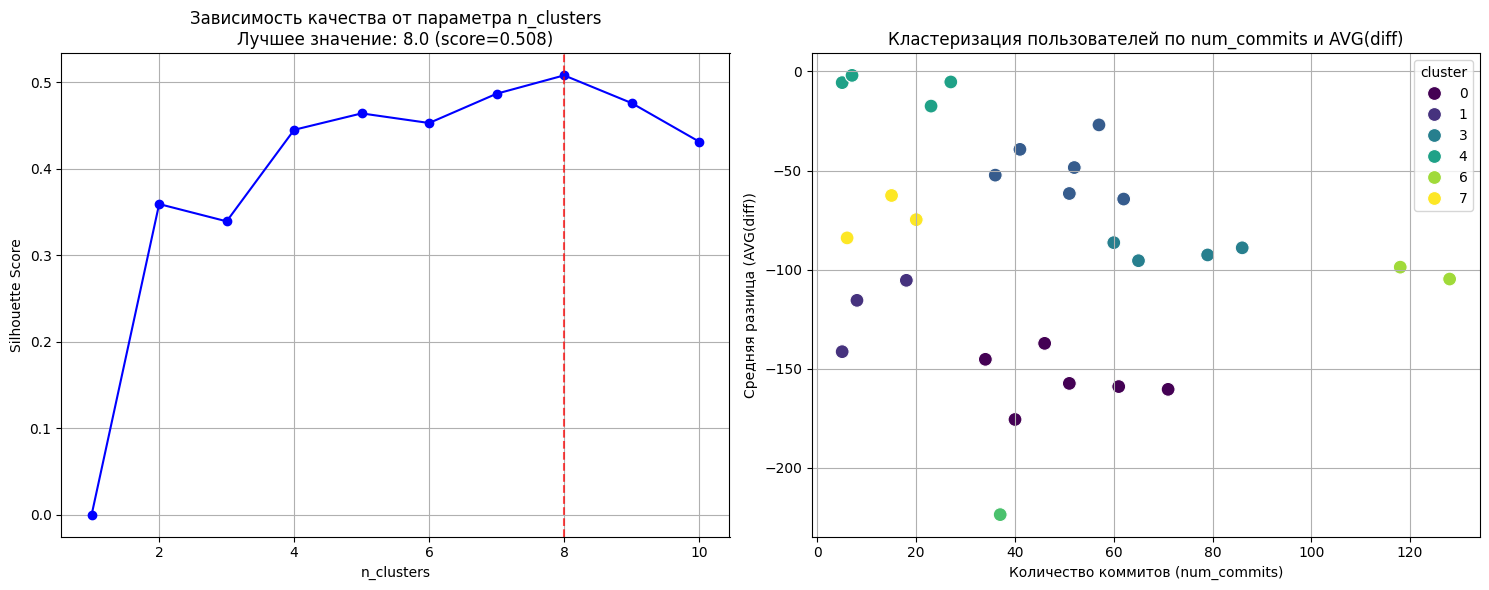

In [22]:
optimize_and_visualize_clustering(
    model_class=AgglomerativeClustering,
    base_params={ 'n_clusters': 5},
    param_name='n_clusters',
    param_range=np.linspace(1, 10, 10),
    X=X,
        
)

22


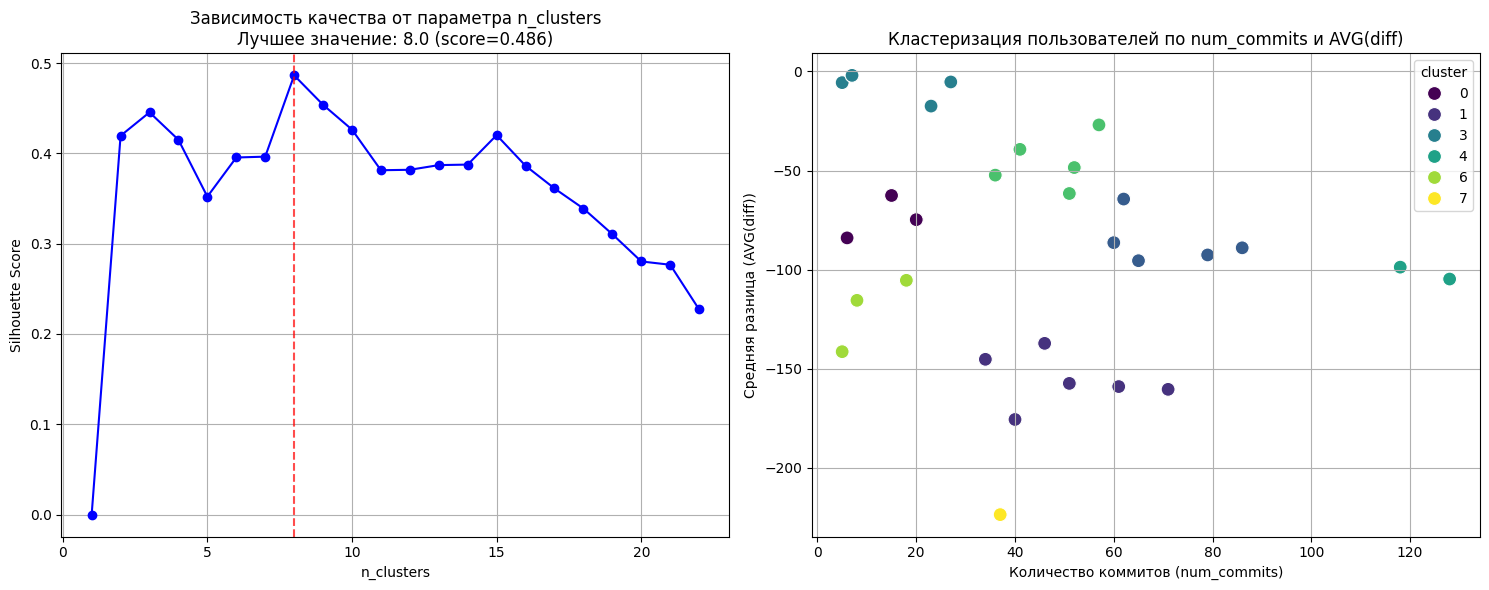

In [23]:
optimize_and_visualize_clustering(
    model_class=KMeans,
    base_params={ 'n_clusters': 3, 'random_state':21},
    param_name='n_clusters',
    param_range=np.linspace(1, 22, 22),
    X=X,
        
)